f# Info

This script performs a Random Forest classification.

The following parameters can be specified:

#### TRAIN_DATA:

The dataset the random forest will be trained on. \

N22 = Northern Bavaria 2022\
N23 = Northern Bavaria 2023\
S20 = Southern Bavaria 2020\
S22 = Southern Bavaria 2022\
ALL = all of the above\

#### VAL_DATA:

The dataset the random forest will be validated on.\

N22 = Northern Bavaria 2022\
N23 = Northern Bavaria 2023\
S20 = Southern Bavaria 2020\
S22 = Southern Bavaria 2022\
ALL = all of the above\

_If VAL_DATA == TRAIN_DATA, as 5-fold Cross Validation will be used._

#### method:

This is the sampling method:\

weighted: Solely minority class ("deadwood") gets oversampled. Specify **weight** as well. Specify **total_n** (number of observations for the model) as well.\
undersampling: All the classes get undersampled to the number of the minority class.\
oversampling: All the classes get oversampled to the number of the majority class ("undisturbed"). Specify, XXXXx as well.




# 1 Import packages and functions

In [16]:
import xarray as xr
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold

In [17]:
from plot_functions import *
from read_functions import *
from datahandling_functions import *
from analysis_functions import *

# 2 Read

In [18]:
chosen_bands = ["blue", "green", "red", "rededge1", "rededge3", "nir", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "contrast"] #options: "blue", "green", "red", "rededge1", "rededge2", "rededge3", "nir", "nir_narrow", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "nssi", "contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"
TRAIN_DATA = "ALL"
VAL_DATA = "ALL"
method = "weighted"
# if method = weight:
weight = 4
FIT = "d"

## 2.1 Read Train

In [19]:
if TRAIN_DATA == "ALL":

    df1 = open_to_pd_df_withregionlabels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n22.tif")
    df2 = open_to_pd_df_withregionlabels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n23.tif")
    df3 = open_to_pd_df_withregionlabels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s20.tif")
    df4 = open_to_pd_df_withregionlabels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s22.tif")
    df = pd.concat([df1, df2, df3, df4], axis=0, ignore_index=True)
    df = df.reset_index()
    final_selection = ["x", "y"] + [b for b in chosen_bands if b not in ["x", "y", "trainclass"]] + ["trainclass", "region", "region_class"]

if TRAIN_DATA != "ALL":

    df = open_to_pd_df(f"C:/Users/miles/OneDrive/Dokumente/ROOT/trainingdata_collection/trainingdata_withindices/{TRAIN_DATA.lower()}.tif")

    final_selection = ["x", "y"] + [b for b in chosen_bands if b not in ["x", "y", "trainclass"]] + ["trainclass"]

df.columns.name = None
df = df.loc[:, ~df.columns.duplicated()]
train_df = df[final_selection]

In [20]:
statistics(df)


--- Dataset Statistics ---
Number of total valid pixels per region and class:
trainclass      1     2       3
region                         
n22         25745  1513  342186
n23         34211   972   97471
s20          7240   354  103224
s22          3234    22  464424

Total valid pixels per region/class (in % of total dataset):
trainclass       1       2        3
region                             
n22         2.38 %  0.14 %  31.67 %
n23         3.17 %  0.09 %   9.02 %
s20         0.67 %  0.03 %   9.55 %
s22          0.3 %   0.0 %  42.98 %


## 2.2 Read Val


In [21]:
if VAL_DATA != TRAIN_DATA:

    val_df = open_to_pd_df(f"C:/Users/miles/OneDrive/Dokumente/ROOT/trainingdata_collection/trainingdata_withindices/{VAL_DATA.lower()}.tif")
    val_df = val_df.reset_index()
    val_df.columns.name = None
    val_df = val_df.loc[:, ~val_df.columns.duplicated()]
    final_selection = ["x", "y"] + [b for b in chosen_bands if b not in ["x", "y", "trainclass"]] + ["trainclass"]
    val_df = val_df[final_selection]

    forestclass_test = val_df["trainclass"]
    pred_test = val_df.drop(columns=["trainclass", "region", "regionclass"])

    forestclass_train = train_df["trainclass"]
    pred_train = train_df.drop(columns=["trainclass", "region", "regionclass"])


if VAL_DATA == TRAIN_DATA:

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pred = df.drop(columns=['trainclass', 'region', 'region_class', "index"])
    forestclass = df['trainclass']
    strat_col = df['region_class']

In [22]:
print("klassen im training")
strat_df = strat_col.value_counts()
print(strat_df / strat_df.sum().sum()*100)

klassen im training
region_class
s22_3    42.978504
n22_3    31.666414
s20_3     9.552506
n23_3     9.020115
n23_1     3.165938
n22_1     2.382482
s20_1     0.670001
s22_1     0.299279
n22_2     0.140015
n23_2     0.089950
s20_2     0.032760
s22_2     0.002036
Name: count, dtype: float64


# 3. TRAIN

In [26]:
if VAL_DATA == TRAIN_DATA:

    all_accuracies = []
    all_f1s = []
    all_cms = []
    cv_predictions = np.zeros_like(forestclass)

    print(f"{'Fold':<10} | {'Accuracy':<10} | {'F1 (Weighted)':<15}")
    print("-" * 45)

    for i, (train_idx, test_idx) in enumerate(skf.split(pred, strat_col)):

        pred_train, pred_test = pred.iloc[train_idx], pred.iloc[test_idx]
        forestclass_train, forestclass_test = forestclass.iloc[train_idx], forestclass.iloc[test_idx]


        coordinates = pred_test[["x", "y"]]
        pred_test = pred_test.drop(columns=["x", "y"])

        # sampling:
        train = pred_train.assign(trainclass = forestclass_train).drop(columns=["x", "y"])
        train = rf_sample(train, method=method, weight = weight)
        forestclass_train = train["trainclass"]
        pred_train = train.drop("trainclass", axis=1)

        rf = randomForestClass(ntrees = 50, pred_train=pred_train, forestclass_train=forestclass_train, FIT = FIT)
        predictions = rf.predict(pred_test)
        cv_predictions[test_idx] = predictions
        acc = accuracy_score(forestclass_test, predictions)

if VAL_DATA != TRAIN_DATA:

    rf = randomForestClass(ntrees = 750, pred_train=pred_train, forestclass_train=forestclass_train)
    predictions = rf.predict(pred_test)

Fold       | Accuracy   | F1 (Weighted)  
---------------------------------------------
unbalanced scikit learn mode was used.
unbalanced scikit learn mode was used.
unbalanced scikit learn mode was used.
unbalanced scikit learn mode was used.
unbalanced scikit learn mode was used.


In [30]:
print(train["trainclass"].value_counts())
print(forestclass_test.value_counts())
print(coordinates)
print(predictions)
print(type(coordinates))
print(type(predictions.to_pd))

trainclass
3    46258
1     3213
2      529
Name: count, dtype: int64
trainclass
3    201462
1     14085
2       572
Name: count, dtype: int64
                    x             y
3        4.421871e+06  3.029437e+06
9        4.421891e+06  3.029427e+06
17       4.421841e+06  3.029407e+06
19       4.421861e+06  3.029407e+06
25       4.421831e+06  3.029397e+06
...               ...           ...
1080584  4.595874e+06  2.836197e+06
1080586  4.595894e+06  2.836197e+06
1080588  4.595774e+06  2.836187e+06
1080589  4.595784e+06  2.836187e+06
1080590  4.595824e+06  2.836187e+06

[216119 rows x 2 columns]
[3 3 3 ... 3 3 3]
<class 'pandas.DataFrame'>


# 4. PLOT

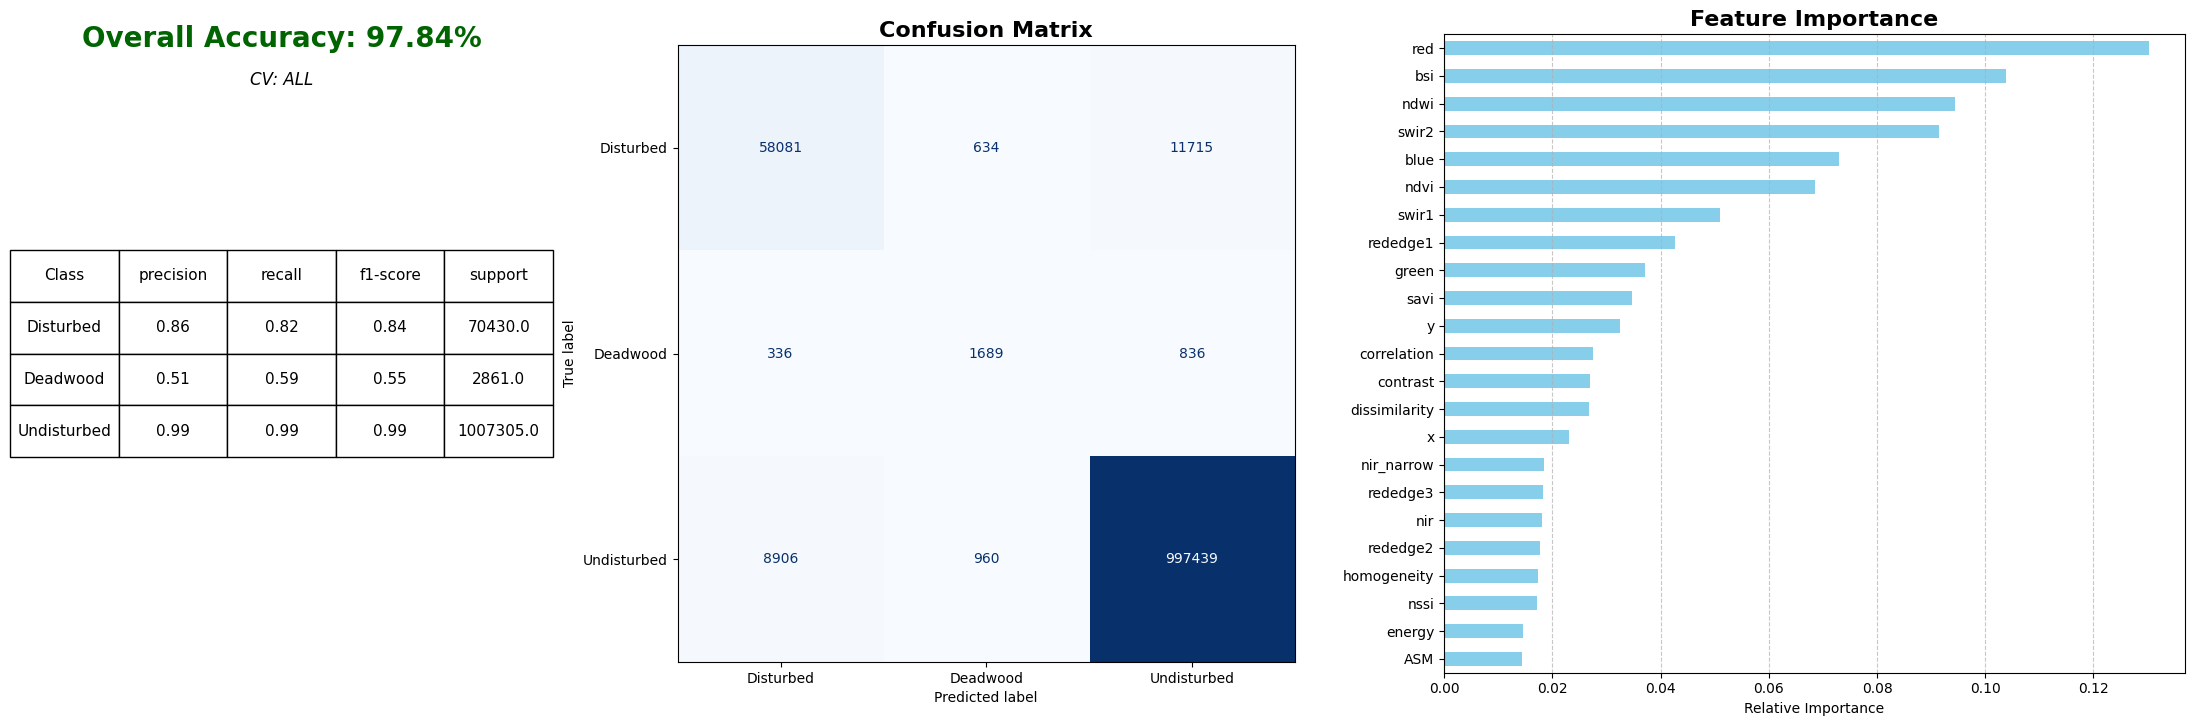

In [12]:
if VAL_DATA == TRAIN_DATA:

    importances = pd.Series(rf.feature_importances_, index=pred.columns)

    fig = plot_cross_model_results(
        y_true=forestclass,
        y_pred=cv_predictions,
        feature_importances=importances,
        train_mode=TRAIN_DATA,
        val_mode=VAL_DATA,
        class_names=['Disturbed', 'Deadwood', 'Undisturbed']
    )

    plt.show()

else:

    fig = plot_model_results(
        y_true=forestclass_test,
        y_pred=predictions,
        rf_model=rf,
        feature_names=chosen_bands,
        train_mode=TRAIN_DATA,
        val_mode=VAL_DATA,)
    plt.show()